# 🧹 Data Cleaning & Merging
🔹 Purpose of this Notebook

This notebook prepares the data for modeling by cleaning, transforming, and merging multiple datasets into a single structured dataset.

🔹 Objectives
- Convert data types into appropriate formats
- Handle missing values and inconsistencies
- Clean important variables such as amount and dates
- Remove irrelevant or redundant features
- Merge all datasets into one dataset
- Prepare data for machine learning

load
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from flaml import AutoML
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
print('Libraries loaded')

Libraries loaded


In [3]:
transactions_bronze = pd.read_parquet('bronze_transactions.parquet')
labels_bronze       = pd.read_parquet('bronze_labels.parquet')
cards_bronze        = pd.read_csv('bronze_cards.csv')
users_bronze        = pd.read_csv('bronze_users.csv')
mcc_bronze          = pd.read_csv('bronze_mcc.csv')

print(f"  Transactions: {transactions_bronze.shape}")
print(f"  Labels      : {labels_bronze.shape}")
print(f"  Cards       : {cards_bronze.shape}")
print(f"  Users       : {users_bronze.shape}")
print(f"  MCC codes   : {mcc_bronze.shape}")

  Transactions: (13305915, 12)
  Labels      : (8914963, 2)
  Cards       : (6146, 13)
  Users       : (2000, 14)
  MCC codes   : (109, 2)


# Data Cleaning

In [4]:
# ============================================================
# CLEAN — TRANSACTIONS STEP 1: Type Conversions
# ============================================================

transactions_clean = transactions_bronze.copy()

# Convert all columns to proper types
transactions_clean['id']          = transactions_clean['id'].astype(int)
transactions_clean['client_id']   = transactions_clean['client_id'].astype(int)
transactions_clean['card_id']     = transactions_clean['card_id'].astype(int)
transactions_clean['merchant_id'] = transactions_clean['merchant_id'].astype(int)
transactions_clean['date']        = pd.to_datetime(
    transactions_clean['date'], errors='coerce')
transactions_clean['mcc']         = pd.to_numeric(
    transactions_clean['mcc'], errors='coerce')
transactions_clean['zip']         = pd.to_numeric(
    transactions_clean['zip'], errors='coerce')

# Check for any dates that failed conversion
bad_dates = transactions_clean['date'].isnull().sum()

print(f"Shape: {transactions_clean.shape}")
print(f"\ndata types:")
print(transactions_clean.dtypes)

Shape: (13305915, 12)

data types:
id                         int32
date              datetime64[ns]
client_id                  int32
card_id                    int32
amount                    object
use_chip                  object
merchant_id                int32
merchant_city             object
merchant_state            object
zip                      float64
mcc                        int64
errors                    object
dtype: object


In [5]:
# Remove $ and comma
amount_clean = (
    transactions_bronze['amount']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

# Check if all values are whole numbers or have decimals
has_decimal = amount_clean.str.contains('\.').sum()
total = len(amount_clean)

print(f"Total amount values  : {total:,}")
print(f"Values with decimals : {has_decimal:,} ({has_decimal/total*100:.2f}%)")
print(f"Values without decimal: {total - has_decimal:,}")

print(f"\nSample values:")
print(amount_clean.head(20).tolist())

Total amount values  : 13,305,915
Values with decimals : 13,305,915 (100.00%)
Values without decimal: 0

Sample values:
['-77.00', '14.57', '80.00', '200.00', '46.41', '4.81', '77.00', '26.46', '261.58', '10.74', '3.51', '2.58', '39.63', '43.33', '49.42', '1.09', '73.79', '100.00', '26.04', '-64.00']


In [6]:
# ============================================================
# CLEAN — AMOUNT: Convert to float and inspect negatives/zeros
# ============================================================

transactions_clean['amount'] = (
    transactions_clean['amount']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(f"\nAmount stats:")
print(transactions_clean['amount'].describe().round(2))


print(f"Negative amounts : {(transactions_clean['amount'] < 0).sum():,} "
      f"({(transactions_clean['amount'] < 0).mean()*100:.2f}%)")
print(f"Zero amounts     : {(transactions_clean['amount'] == 0).sum():,} "
      f"({(transactions_clean['amount'] == 0).mean()*100:.2f}%)")
print(f"Positive amounts : {(transactions_clean['amount'] > 0).sum():,} "
      f"({(transactions_clean['amount'] > 0).mean()*100:.2f}%)")

print(f"\nNegative amount samples:")
neg = transactions_clean[transactions_clean['amount'] < 0]['amount']
print(neg.head(10).tolist())
print(f"\nNegative amount stats:")
print(neg.describe().round(2))

print(f"\nZero amount samples (if any):")
zeros = transactions_clean[transactions_clean['amount'] == 0]
print(f"Count: {len(zeros):,}")
if len(zeros) > 0:
    display(zeros.head(5))


Amount stats:
count    13305915.00
mean           42.98
std            81.66
min          -500.00
25%             8.93
50%            28.99
75%            63.71
max          6820.20
Name: amount, dtype: float64
Negative amounts : 660,049 (4.96%)
Zero amounts     : 10,639 (0.08%)
Positive amounts : 12,635,227 (94.96%)

Negative amount samples:
[-77.0, -64.0, -78.0, -460.0, -147.0, -84.0, -148.0, -66.0, -86.0, -95.0]

Negative amount stats:
count    660049.00
mean       -102.29
std          84.96
min        -500.00
25%         -93.00
50%         -79.00
75%         -64.00
max          -0.01
Name: amount, dtype: float64

Zero amount samples (if any):
Count: 10,639


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
2323,7478107,2010-01-01 15:43:00,961,2201,0.0,Swipe Transaction,27092,Wilkes Barre,PA,18706.0,4829,None
2590,7478430,2010-01-01 17:00:00,614,2953,0.0,Swipe Transaction,27092,Gastonia,NC,28056.0,4829,None
5913,7482377,2010-01-02 18:13:00,614,2094,0.0,Swipe Transaction,27092,Gastonia,NC,28056.0,4829,None
9186,7486309,2010-01-03 17:50:00,614,2953,0.0,Swipe Transaction,27092,Gastonia,NC,28056.0,4829,None
10437,7487812,2010-01-04 08:18:00,1184,2898,0.0,Swipe Transaction,27092,Hayward,CA,94544.0,4829,None


In [7]:
# ============================================================
# INSPECT — Remaining Transaction Columns
# ============================================================

# 1. use_chip
print("1. USE_CHIP:")
print(transactions_clean['use_chip'].value_counts())
print(f"Missing: {transactions_clean['use_chip'].isnull().sum()}")

# 2. merchant_city
print(f"\n2. MERCHANT_CITY:")
print(f"Missing: {transactions_clean['merchant_city'].isnull().sum()}")
print(f"Unique values: {transactions_clean['merchant_city'].nunique():,}")
print(f"Top 10:\n{transactions_clean['merchant_city'].value_counts().head(10)}")

# 3. merchant_state
print(f"\n3. MERCHANT_STATE:")
print(f"Missing: {transactions_clean['merchant_state'].isnull().sum():,} ({transactions_clean['merchant_state'].isnull().mean()*100:.2f}%)")
print(f"Unique values: {transactions_clean['merchant_state'].nunique():,}")
print(f"Top 10:\n{transactions_clean['merchant_state'].value_counts().head(10)}")
print(f"Bottom 5 (least common):\n{transactions_clean['merchant_state'].value_counts().tail(5)}")

# 4. zip
print(f"\n4. ZIP:")
print(f"Missing: {transactions_clean['zip'].isnull().sum():,} ({transactions_clean['zip'].isnull().mean()*100:.2f}%)")
print(f"Unique values: {transactions_clean['zip'].nunique():,}")

# 5. mcc
print(f"\n5. MCC:")
print(f"Missing: {transactions_clean['mcc'].isnull().sum()}")
print(f"Unique values: {transactions_clean['mcc'].nunique()}")
print(f"Sample values: {transactions_clean['mcc'].value_counts().head(10)}")

# 6. errors
print(f"\n6. ERRORS:")
print(f"Missing: {transactions_clean['errors'].isnull().sum():,} ({transactions_clean['errors'].isnull().mean()*100:.2f}%)")
print(f"Unique error types: {transactions_clean['errors'].nunique()}")
print(f"Distribution:\n{transactions_clean['errors'].value_counts()}")

# 7. date features check
print(f"\n7. DATE CHECK:")
print(f"Missing dates: {transactions_clean['date'].isnull().sum()}")
print(f"Date range: {transactions_clean['date'].min()} to {transactions_clean['date'].max()}")
print(f"Years: {sorted(transactions_clean['date'].dt.year.unique())}")
print(f"Any future dates: {(transactions_clean['date'].dt.year > 2026).sum()}")

1. USE_CHIP:
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: use_chip, dtype: int64
Missing: 0

2. MERCHANT_CITY:
Missing: 0
Unique values: 12,492
Top 10:
ONLINE          1563700
Houston          146917
Miami             87388
Brooklyn          84020
Los Angeles       82004
Chicago           72540
Dallas            71864
Louisville        66088
Philadelphia      61419
San Antonio       59265
Name: merchant_city, dtype: int64

3. MERCHANT_STATE:
Missing: 1,563,700 (11.75%)
Unique values: 199
Top 10:
CA    1427087
TX    1010207
NY     857510
FL     701623
OH     484122
IL     467931
NC     429427
PA     417766
MI     397970
GA     368206
Name: merchant_state, dtype: int64
Bottom 5 (least common):
Equatorial Guinea    3
Brunei               3
Solomon Islands      3
Tonga                2
Azerbaijan           2
Name: merchant_state, dtype: int64

4. ZIP:
Missing: 1,652,706 (12.42%)
Unique values: 25,256

5. MCC:
Missing: 0
Unique values: 109


In [8]:
# ============================================================
# INVESTIGATE — Are missing states = online transactions?
# ============================================================

# Check if missing merchant_state aligns with ONLINE city
online_mask   = transactions_clean['merchant_city'] == 'ONLINE'
missing_state = transactions_clean['merchant_state'].isnull()
missing_zip   = transactions_clean['zip'].isnull()

print("Online transactions (merchant_city = ONLINE):")
print(f"  Count: {online_mask.sum():,}")

print(f"\nMissing merchant_state: {missing_state.sum():,}")
print(f"Missing zip           : {missing_zip.sum():,}")

print(f"\nOf the ONLINE transactions:")
print(f"  Missing state: {(online_mask & missing_state).sum():,}")
print(f"  Missing zip  : {(online_mask & missing_zip).sum():,}")

print(f"\nOf the missing states:")
print(f"  Are ONLINE   : {(missing_state & online_mask).sum():,}")
print(f"  Are NOT ONLINE: {(missing_state & ~online_mask).sum():,}")

print(f"\nOf the missing zips:")
print(f"  Are ONLINE   : {(missing_zip & online_mask).sum():,}")
print(f"  Are NOT ONLINE: {(missing_zip & ~online_mask).sum():,}")

# Check use_chip for missing state rows
print(f"\nuse_chip distribution for missing state rows:")
print(transactions_clean[missing_state]['use_chip'].value_counts())

Online transactions (merchant_city = ONLINE):
  Count: 1,563,700

Missing merchant_state: 1,563,700
Missing zip           : 1,652,706

Of the ONLINE transactions:
  Missing state: 1,563,700
  Missing zip  : 1,563,700

Of the missing states:
  Are ONLINE   : 1,563,700
  Are NOT ONLINE: 0

Of the missing zips:
  Are ONLINE   : 1,563,700
  Are NOT ONLINE: 89,006

use_chip distribution for missing state rows:
Online Transaction    1557912
Chip Transaction         5788
Name: use_chip, dtype: int64


In [9]:
transactions_clean['is_refund'] = (
    transactions_clean['amount'] < 0).astype(int)

# Take absolute value
transactions_clean['amount'] = transactions_clean['amount'].abs()

print(f"Amount cleaned")
print(f"is_refund flag created: {transactions_clean['is_refund'].sum():,} refunds")
print(f"\nAmount stats after cleaning:")
print(transactions_clean['amount'].describe().round(2))

Amount cleaned
is_refund flag created: 660,049 refunds

Amount stats after cleaning:
count    13305915.00
mean           53.12
std            75.45
min             0.00
25%            11.75
50%            34.80
75%            71.00
max          6820.20
Name: amount, dtype: float64


In [10]:
transactions_clean['is_zero_amount'] = (
    transactions_clean['amount'] == 0
).astype(int)

**Interpretation:**

- Negative transaction amounts represent refunds
- Approximately 5% of transactions are refunds
- Refunds are handled by creating a new feature (is_refund) and converting amounts to positive values

In [11]:
# --- MERCHANT STATE ---
# Fill missing as ONLINE (structural missing)
transactions_clean['merchant_state'] = transactions_clean['merchant_state'].fillna('ONLINE')

**Interpretation:**

* Missing `merchant_state` values correspond entirely to online transactions
* This indicates structural missing data rather than data quality issues
* Missing values are handled by labeling them as "ONLINE"


In [12]:
transactions_clean['errors'] = (
    transactions_bronze['errors'].fillna('No Error'))

# Simplify compounds — take first error only
transactions_clean['errors'] = (
    transactions_clean['errors']
    .str.split(',').str[0].str.strip())

# Verify result
print("AFTER simplification:")
print(transactions_clean['errors'].value_counts())
print(f"\nUnique categories: {transactions_clean['errors'].nunique()}")
print(f"Missing: {transactions_clean['errors'].isnull().sum()}")

AFTER simplification:
No Error                13094522
Insufficient Balance      131145
Bad PIN                    32482
Technical Glitch           26271
Bad Card Number             7925
Bad Expiration              6261
Bad CVV                     6171
Bad Zipcode                 1138
Name: errors, dtype: int64

Unique categories: 8
Missing: 0


In [ ]:

# # --- ZIP ---
# # Too high cardinality → drop
transactions_clean = transactions_clean.drop(columns=['zip'])


# # --- ERRORS ---
# # SAFEST OPTION → drop (to avoid leakage)
transactions_clean = transactions_clean.drop(columns=['errors'])


transactions_clean = transactions_clean.drop(
   columns=['merchant_id', 'merchant_city'])

**Interpretation:**

* `zip` was removed due to high cardinality
* `errors` was dropped to avoid potential data leakage
* `merchant_id` and `merchant_city` were removed as they are not useful for modeling


In [14]:
print(transactions_clean.columns)
print(transactions_clean.dtypes)
print(transactions_clean.isnull().sum())

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_state', 'mcc', 'is_refund', 'is_zero_amount'],
      dtype='object')
id                         int32
date              datetime64[ns]
client_id                  int32
card_id                    int32
amount                   float64
use_chip                  object
merchant_state            object
mcc                        int64
is_refund                  int32
is_zero_amount             int32
dtype: object
id                0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_state    0
mcc               0
is_refund         0
is_zero_amount    0
dtype: int64


### Save the cleaned file to resuse in future if needed

In [ ]:
#svaing cleaned verison to reuse in future if needed before merging
transactions_clean.to_parquet('transactions_clean.parquet', index=False)


In [16]:
# ============================================================
# CLEAN — CARDS
# Based on EDA findings
# ============================================================

cards_clean = cards_bronze.copy()

print(f"\ncard_on_dark_web unique: {cards_clean['card_on_dark_web'].nunique()}")
print(f"credit_limit sample: {cards_clean['credit_limit'].head(5).tolist()}")
print(f"credit_limit $0 count: {(cards_clean['credit_limit'] == '$0').sum()}")
print(f"\nacct_open_date sample: {cards_clean['acct_open_date'].head(3).tolist()}")
print(f"expires sample: {cards_clean['expires'].head(3).tolist()}")
print(f"\nnum_cards_issued: {cards_clean['num_cards_issued'].value_counts().to_dict()}")
print(f"year_pin_last_changed: {cards_clean['year_pin_last_changed'].value_counts().sort_index().to_dict()}")


card_on_dark_web unique: 1
credit_limit sample: ['$24295', '$21968', '$46414', '$12400', '$28']
credit_limit $0 count: 31

acct_open_date sample: ['09/2002', '04/2014', '07/2003']
expires sample: ['12/2022', '12/2020', '02/2024']

num_cards_issued: {1: 3114, 2: 2972, 3: 60}
year_pin_last_changed: {2002: 2, 2003: 11, 2004: 12, 2005: 36, 2006: 73, 2007: 177, 2008: 303, 2009: 456, 2010: 712, 2011: 809, 2012: 477, 2013: 465, 2014: 397, 2015: 341, 2016: 234, 2017: 162, 2018: 156, 2019: 115, 2020: 1208}


In [17]:
cards_clean = cards_clean.drop(
    columns=['card_on_dark_web', 'card_number', 'cvv'])

print(f"Dropped: card_on_dark_web, card_number, cvv")

Dropped: card_on_dark_web, card_number, cvv


In [18]:
cards_clean['credit_limit'] = (
    cards_clean['credit_limit']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(f"\ncredit_limit after cleaning:")
print(cards_clean['credit_limit'].describe().round(2))
print(f"$0 limits: {(cards_clean['credit_limit'] == 0).sum()}")


credit_limit after cleaning:
count      6146.00
mean      14347.49
std       12014.46
min           0.00
25%        7042.75
50%       12592.50
75%       19156.50
max      151223.00
Name: credit_limit, dtype: float64
$0 limits: 31


In [19]:
cards_clean['has_chip'] = (
    cards_clean['has_chip'] == 'YES').astype(int)

print(f"\nhas_chip after encoding:")
print(cards_clean['has_chip'].value_counts())


has_chip after encoding:
1    5500
0     646
Name: has_chip, dtype: int64


In [20]:
cards_clean['acct_open_date'] = pd.to_datetime(
    cards_clean['acct_open_date'], format='%m/%Y', errors='coerce')
cards_clean['expires'] = pd.to_datetime(
    cards_clean['expires'], format='%m/%Y', errors='coerce')

print(f"\nacct_open_date range:")
print(f"  Min: {cards_clean['acct_open_date'].min()}")
print(f"  Max: {cards_clean['acct_open_date'].max()}")
print(f"  Missing: {cards_clean['acct_open_date'].isnull().sum()}")

print(f"\nexpires range:")
print(f"  Min: {cards_clean['expires'].min()}")
print(f"  Max: {cards_clean['expires'].max()}")
print(f"  Missing: {cards_clean['expires'].isnull().sum()}")



acct_open_date range:
  Min: 1991-01-01 00:00:00
  Max: 2020-02-01 00:00:00
  Missing: 0

expires range:
  Min: 1997-07-01 00:00:00
  Max: 2024-12-01 00:00:00
  Missing: 0


In [21]:
print(f"Shape         : {cards_clean.shape}")
print(f"Missing values: {cards_clean.isnull().sum().sum()}")
print(f"\nColumns:")
for col in cards_clean.columns:
    print(f"  {col:20s}: {str(cards_clean[col].dtype):12s} | "
          f"{cards_clean[col].nunique():,} unique")


Shape         : (6146, 10)
Missing values: 0

Columns:
  id                  : int64        | 6,146 unique
  client_id           : int64        | 2,000 unique
  card_brand          : object       | 4 unique
  card_type           : object       | 3 unique
  expires             : datetime64[ns] | 259 unique
  has_chip            : int32        | 2 unique
  num_cards_issued    : int64        | 3 unique
  credit_limit        : float64      | 3,654 unique
  acct_open_date      : datetime64[ns] | 303 unique
  year_pin_last_changed: int64        | 19 unique


**Interpretation:**

* Sensitive and irrelevant features such as `card_number` and `cvv` were removed
* Credit limit was converted into numeric format
* `has_chip` was encoded into binary form


### Save the cleaned file to resuse in future if needed

In [ ]:
#svaing cleaned verison to reuse in future if needed before merging
cards_clean.to_parquet('cards_silver.parquet', index=False)

In [ ]:
# ============================================================
# CLEAN — USERS
# Based on EDA findings
# ============================================================


users_clean = users_bronze.copy()

# Drop redundant/useless columns
users_clean = users_clean.drop(
    columns=['birth_year', 'birth_month', 'address', 'latitude', 'longitude'])

# Clean income columns
for col in ['per_capita_income', 'yearly_income', 'total_debt']:
    users_clean[col] = (
        users_clean[col]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float))

print("Users cleaned")
print(f"Shape: {users_clean.shape}")
print(f"Missing: {users_clean.isnull().sum().sum()}")
print(f"\nColumns:")
for col in users_clean.columns:
    print(f"  {col:25s}: {str(users_clean[col].dtype):15s} | {users_clean[col].nunique():,} unique")


print("\n4. Already retired (retirement_age <= current_age):")
retired = users_bronze[
    users_bronze['retirement_age'] <= users_bronze['current_age']]
print(f"Count: {len(retired)}")
print(f"Age range of retired: {retired['current_age'].min()} "
      f"to {retired['current_age'].max()}")

print("\n5. birth_year vs current_age check:")
# If data is from ~2019, birth_year + current_age should ≈ 2019
check = users_bronze['birth_year'] + users_bronze['current_age']
print(f"birth_year + current_age range: {check.min()} to {check.max()}")
print(f"Expected ~2019, actual mean: {check.mean():.0f}")

Users cleaned
Shape: (2000, 9)
Missing: 0

Columns:
  id                       : int64           | 2,000 unique
  current_age              : int64           | 80 unique
  retirement_age           : int64           | 29 unique
  gender                   : object          | 2 unique
  per_capita_income        : float64         | 1,754 unique
  yearly_income            : float64         | 1,948 unique
  total_debt               : float64         | 1,880 unique
  credit_score             : int64           | 321 unique
  num_credit_cards         : int64           | 9 unique

4. Already retired (retirement_age <= current_age):
Count: 302
Age range of retired: 56 to 101

5. birth_year vs current_age check:
birth_year + current_age range: 2019 to 2020
Expected ~2019, actual mean: 2019


In [24]:
print(f"\nUSERS SILVER — FINAL")
print(f"{'='*55}")
print(f"Shape         : {users_clean.shape}")
print(f"Missing values: {users_clean.isnull().sum().sum()}")
print(f"\nColumns:")
for col in users_clean.columns:
    print(f"  {col:20s}: {str(users_clean[col].dtype):12s} | "
          f"{users_clean[col].nunique():,} unique")


USERS SILVER — FINAL
Shape         : (2000, 9)
Missing values: 0

Columns:
  id                  : int64        | 2,000 unique
  current_age         : int64        | 80 unique
  retirement_age      : int64        | 29 unique
  gender              : object       | 2 unique
  per_capita_income   : float64      | 1,754 unique
  yearly_income       : float64      | 1,948 unique
  total_debt          : float64      | 1,880 unique
  credit_score        : int64        | 321 unique
  num_credit_cards    : int64        | 9 unique


**Interpretation:**

* Redundant columns such as location and birth details were removed
* Income-related features were converted into numeric format
* The dataset is clean with no missing values

### Save the cleaned file to resuse in future if needed

In [ ]:
#svaing cleaned verison to reuse in future if needed before merging
users_clean.to_parquet('users_silver.parquet', index=False)

In [26]:
mcc_clean = mcc_bronze.copy()
mcc_clean['mcc_code'] = pd.to_numeric(mcc_clean['mcc_code'], errors= 'coerce')

In [ ]:
# labels_bronze.to_csv('labels_silver.csv', index=False)
# print("Labels saved for reference")
# print(f"Shape: {labels_bronze.shape}")
# print(f"Fraud rate: {labels_bronze['is_fraud'].mean()*100:.4f}%")

In [ ]:
# mcc_df = pd.read_json('mcc_codes.json', typ='series').reset_index()
# mcc_df.columns = ['mcc', 'mcc_description']
# mcc_df.to_csv('mcc.csv', index=False)

# 🔗 Data Merging


In [29]:
# Step 1: transactions + labels
df_silver = transactions_clean.merge(labels_bronze, on='id', how='inner')
print(f"After joining labels : {df_silver.shape} | Fraud rate: {df_silver['is_fraud'].mean()*100:.4f}%")

# Step 2: + cards
df_silver = df_silver.merge(
    cards_clean, left_on='card_id', right_on='id',
    suffixes=('', '_card'), how='left')
df_silver = df_silver.drop(columns=['id_card', 'client_id_card'], errors='ignore')
print(f"After joining cards  : {df_silver.shape}")

# Step 3: + users
df_silver = df_silver.merge(
    users_clean, left_on='client_id', right_on='id',
    suffixes=('', '_user'), how='left')
df_silver = df_silver.drop(columns=['id_user'], errors='ignore')
print(f"After joining users  : {df_silver.shape}")

# Step 4: + mcc codes
df_silver = df_silver.merge(
    mcc_bronze, left_on='mcc', right_on='mcc_code', how='left')
df_silver = df_silver.drop(columns=['mcc_code'], errors='ignore')
print(f"After joining MCC   : {df_silver.shape}")

# Verify
print(f"\nSILVER MERGED")
print(f"{'='*55}")
print(f"Shape      : {df_silver.shape}")
print(f"Fraud cases: {df_silver['is_fraud'].sum():,}")
print(f"Legit cases: {(df_silver['is_fraud']==0).sum():,}")
print(f"Fraud rate : {df_silver['is_fraud'].mean()*100:.4f}%")
print(f"Missing    : {df_silver.isnull().sum().sum()}")
print(f"\nColumns: {df_silver.columns.tolist()}")

After joining labels : (8914963, 11) | Fraud rate: 0.1495%
After joining cards  : (8914963, 19)
After joining users  : (8914963, 27)
After joining MCC   : (8914963, 28)

SILVER MERGED
Shape      : (8914963, 28)
Fraud cases: 13,332
Legit cases: 8,901,631
Fraud rate : 0.1495%
Missing    : 0

Columns: ['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip', 'merchant_state', 'mcc', 'is_refund', 'is_zero_amount', 'is_fraud', 'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'current_age', 'retirement_age', 'gender', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'mcc_description']


**Interpretation:**

* All datasets were successfully merged into a single dataset
* The final dataset contains over 8.9 million records and multiple features
* No missing values remain after merging
* The dataset is ready for feature engineering and modeling


In [30]:
# ============================================================
# VERIFY — Silver Merged
# ============================================================

print("SILVER MERGED — VERIFICATION")
print(f"{'='*55}")
print(f"Shape         : {df_silver.shape}")
print(f"Fraud cases   : {df_silver['is_fraud'].sum():,}")
print(f"Legit cases   : {(df_silver['is_fraud']==0).sum():,}")
print(f"Fraud rate    : {df_silver['is_fraud'].mean()*100:.4f}%")

print(f"\nMissing values:")
missing = df_silver.isnull().sum()
missing_pct = (missing/len(df_silver)*100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct%': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print(f"\nAll columns ({len(df_silver.columns)}):")
for col in df_silver.columns:
    print(f"  {col:25s}: {str(df_silver[col].dtype):15s} | "
          f"{df_silver[col].nunique():,} unique")


SILVER MERGED — VERIFICATION
Shape         : (8914963, 28)
Fraud cases   : 13,332
Legit cases   : 8,901,631
Fraud rate    : 0.1495%

Missing values:
Empty DataFrame
Columns: [Count, Pct%]
Index: []

All columns (28):
  id                       : int32           | 8,914,963 unique
  date                     : datetime64[ns]  | 3,680,988 unique
  client_id                : int32           | 1,219 unique
  card_id                  : int32           | 4,070 unique
  amount                   : float64         | 70,084 unique
  use_chip                 : object          | 3 unique
  merchant_state           : object          | 200 unique
  mcc                      : int64           | 109 unique
  is_refund                : int32           | 2 unique
  is_zero_amount           : int32           | 2 unique
  is_fraud                 : int32           | 2 unique
  card_brand               : object          | 4 unique
  card_type                : object          | 3 unique
  expires             

# meaningful visualizations to understand data distributions and relationships

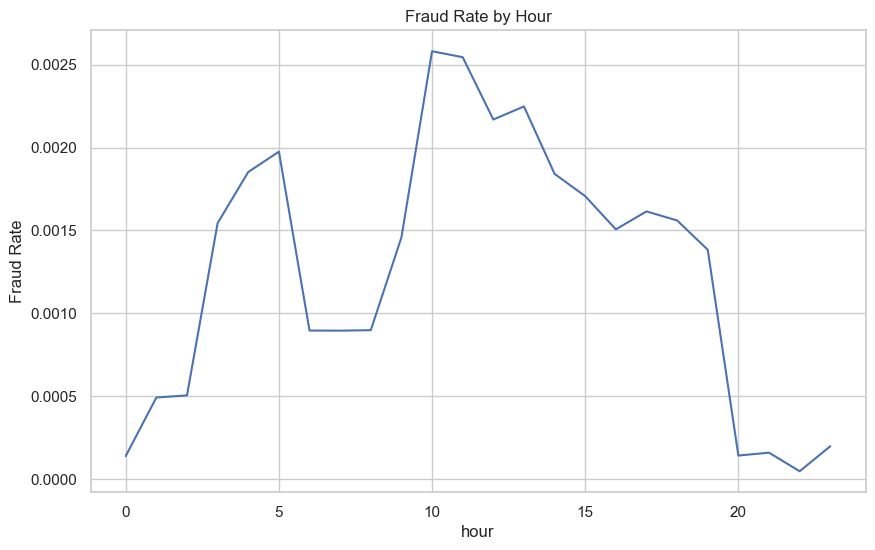

In [31]:
df_silver['hour'] = pd.to_datetime(
    df_silver['date'], errors='coerce'
).dt.hour

df_silver.groupby('hour')['is_fraud'].mean().plot()
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.show()

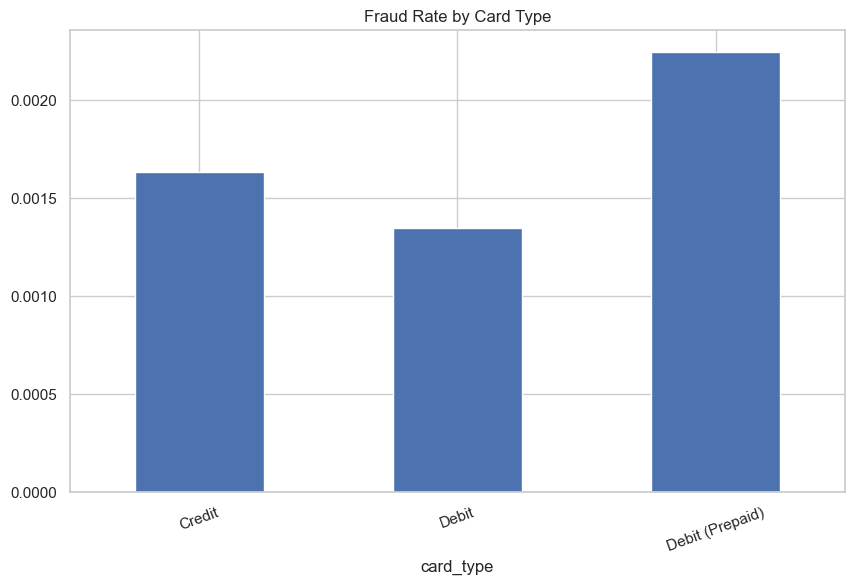

In [32]:
df_silver.groupby('card_type')['is_fraud'].mean().plot(kind='bar')
plt.title("Fraud Rate by Card Type")
plt.xticks(rotation=20)
plt.show()

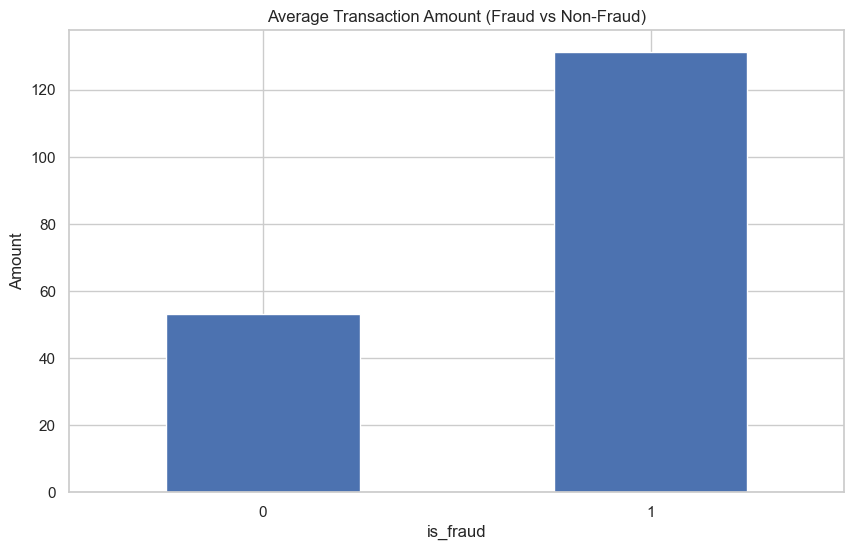

In [33]:
df_silver.groupby('is_fraud')['amount'].mean().plot(kind='bar')
plt.title("Average Transaction Amount (Fraud vs Non-Fraud)")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

In [34]:
df_silver.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_state', 'mcc', 'is_refund', 'is_zero_amount', 'is_fraud',
       'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued',
       'credit_limit', 'acct_open_date', 'year_pin_last_changed',
       'current_age', 'retirement_age', 'gender', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
       'mcc_description', 'hour'],
      dtype='object')

In [ ]:
# Save the merged data to use further
df_silver.to_parquet('silver_merged.parquet', index=False)

print(f"  silver_merged.parquet — {df_silver.shape}")
print(f"  silver_merged.csv")


  silver_merged.parquet — (8914963, 29)
  silver_merged.csv


**Interpretation:**

* All five datasets (transactions, fraud labels, cards, users, and MCC codes) were successfully combined into a single dataset

* No missing values remain after merging
